In [12]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [13]:
df = pd.read_csv("../data/raw/vietnam_weather_2023_complete.csv")

# Datapreprocess

1. Encoding

In [14]:
col = df.dtypes == 'object'
col = df.columns[col]
col

Index(['city', 'date', 'sunrise', 'sunset'], dtype='object')

In [15]:
df_encode = df.copy()

transform time object from  str to time

In [16]:
df_encode['sunrise'] = pd.to_datetime(df_encode['sunrise']).dt.time
df_encode['sunset'] = pd.to_datetime(df_encode['sunset']).dt.time
df_encode['date'] = pd.to_datetime(df_encode['date'])
df_encode[['sunrise', 'sunset', 'date']]

,sunrise,sunset,date
0,06:33:00,17:26:00,2022-01-01
1,06:34:00,17:27:00,2022-01-02
2,06:34:00,17:27:00,2022-01-03
3,06:34:00,17:28:00,2022-01-04
4,06:34:00,17:28:00,2022-01-05
...,...,...,...
13147,06:10:00,17:40:00,2024-12-27
13148,06:10:00,17:41:00,2024-12-28
13149,06:10:00,17:41:00,2024-12-29
13150,06:11:00,17:42:00,2024-12-30


In [17]:
col_int = df_encode.dtypes == 'int64'
col_int = df_encode.columns[col_int]
df_encode[col_int] = df_encode[col_int].astype('float64')

2. Outlier

2.1. Scaler

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
z_scaler = StandardScaler()

cols_num = df_encode.select_dtypes(include=['float64', 'int64']).columns
cols_num = cols_num.drop(['latitude', 'longitude', 'weather_code'])
df_scaler = df_encode.copy()
df_scaler[cols_num] = scaler.fit_transform(df_scaler[cols_num])
df_scaler

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,wind_direction_10m_dominant,shortwave_radiation_sum,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,dewpoint_2m_max,dewpoint_2m_min,dewpoint_2m_mean,surface_pressure_mean,cloudcover_mean
0,Hanoi,21.0278,105.8342,2022-01-01,-2.106383,-2.941176,-2.771429,-0.207317,-0.5,3.0,...,-0.774834,-1.398542,-1.000000,-0.388889,-0.842105,-3.305556,-2.511111,-2.984093,2.235529,0.352035
1,Hanoi,21.0278,105.8342,2022-01-02,-1.914894,-2.647059,-2.685714,-0.207317,-0.5,3.0,...,-0.821192,-0.707169,-1.833333,-0.500000,-1.172932,-3.138889,-2.688889,-3.125371,1.974717,-0.779978
2,Hanoi,21.0278,105.8342,2022-01-03,-1.872340,-3.235294,-2.571429,-0.207317,-0.5,3.0,...,-0.026490,-1.166464,0.666667,-0.277778,-0.251880,-2.750000,-2.088889,-2.492316,1.556221,-0.676568
3,Hanoi,21.0278,105.8342,2022-01-04,-1.425532,-3.088235,-2.400000,-0.207317,-0.5,3.0,...,0.052980,-1.127582,0.666667,-0.444444,0.131579,-2.083333,-1.977778,-2.176328,1.204258,-0.625963
4,Hanoi,21.0278,105.8342,2022-01-05,-1.404255,-2.029412,-1.942857,-0.207317,-0.5,3.0,...,0.165563,-1.404617,0.666667,-0.222222,0.131579,-1.722222,-1.400000,-1.733082,0.952096,-0.277228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13147,Long An,10.5336,106.4110,2024-12-27,0.021277,-0.147059,-0.142857,1.878049,0.0,65.0,...,-0.476821,-0.340219,0.166667,0.055556,0.270677,-0.055556,0.044444,-0.032354,0.669328,0.026403
13148,Long An,10.5336,106.4110,2024-12-28,-0.148936,-0.264706,-0.285714,0.560976,0.2,63.0,...,-0.456954,-0.312272,0.666667,0.333333,0.612782,-0.111111,0.155556,0.003235,0.685296,0.019802
13149,Long An,10.5336,106.4110,2024-12-29,-0.148936,-0.705882,-0.342857,-0.207317,-0.5,3.0,...,1.456954,0.122722,0.333333,-0.388889,-0.142857,-0.527778,-0.422222,-0.497169,0.590818,-1.189219
13150,Long An,10.5336,106.4110,2024-12-30,-0.063830,-1.029412,-0.371429,-0.207317,-0.5,3.0,...,1.086093,0.217497,0.000000,-0.388889,-0.515038,-0.611111,-0.866667,-0.727959,0.558217,-0.557756


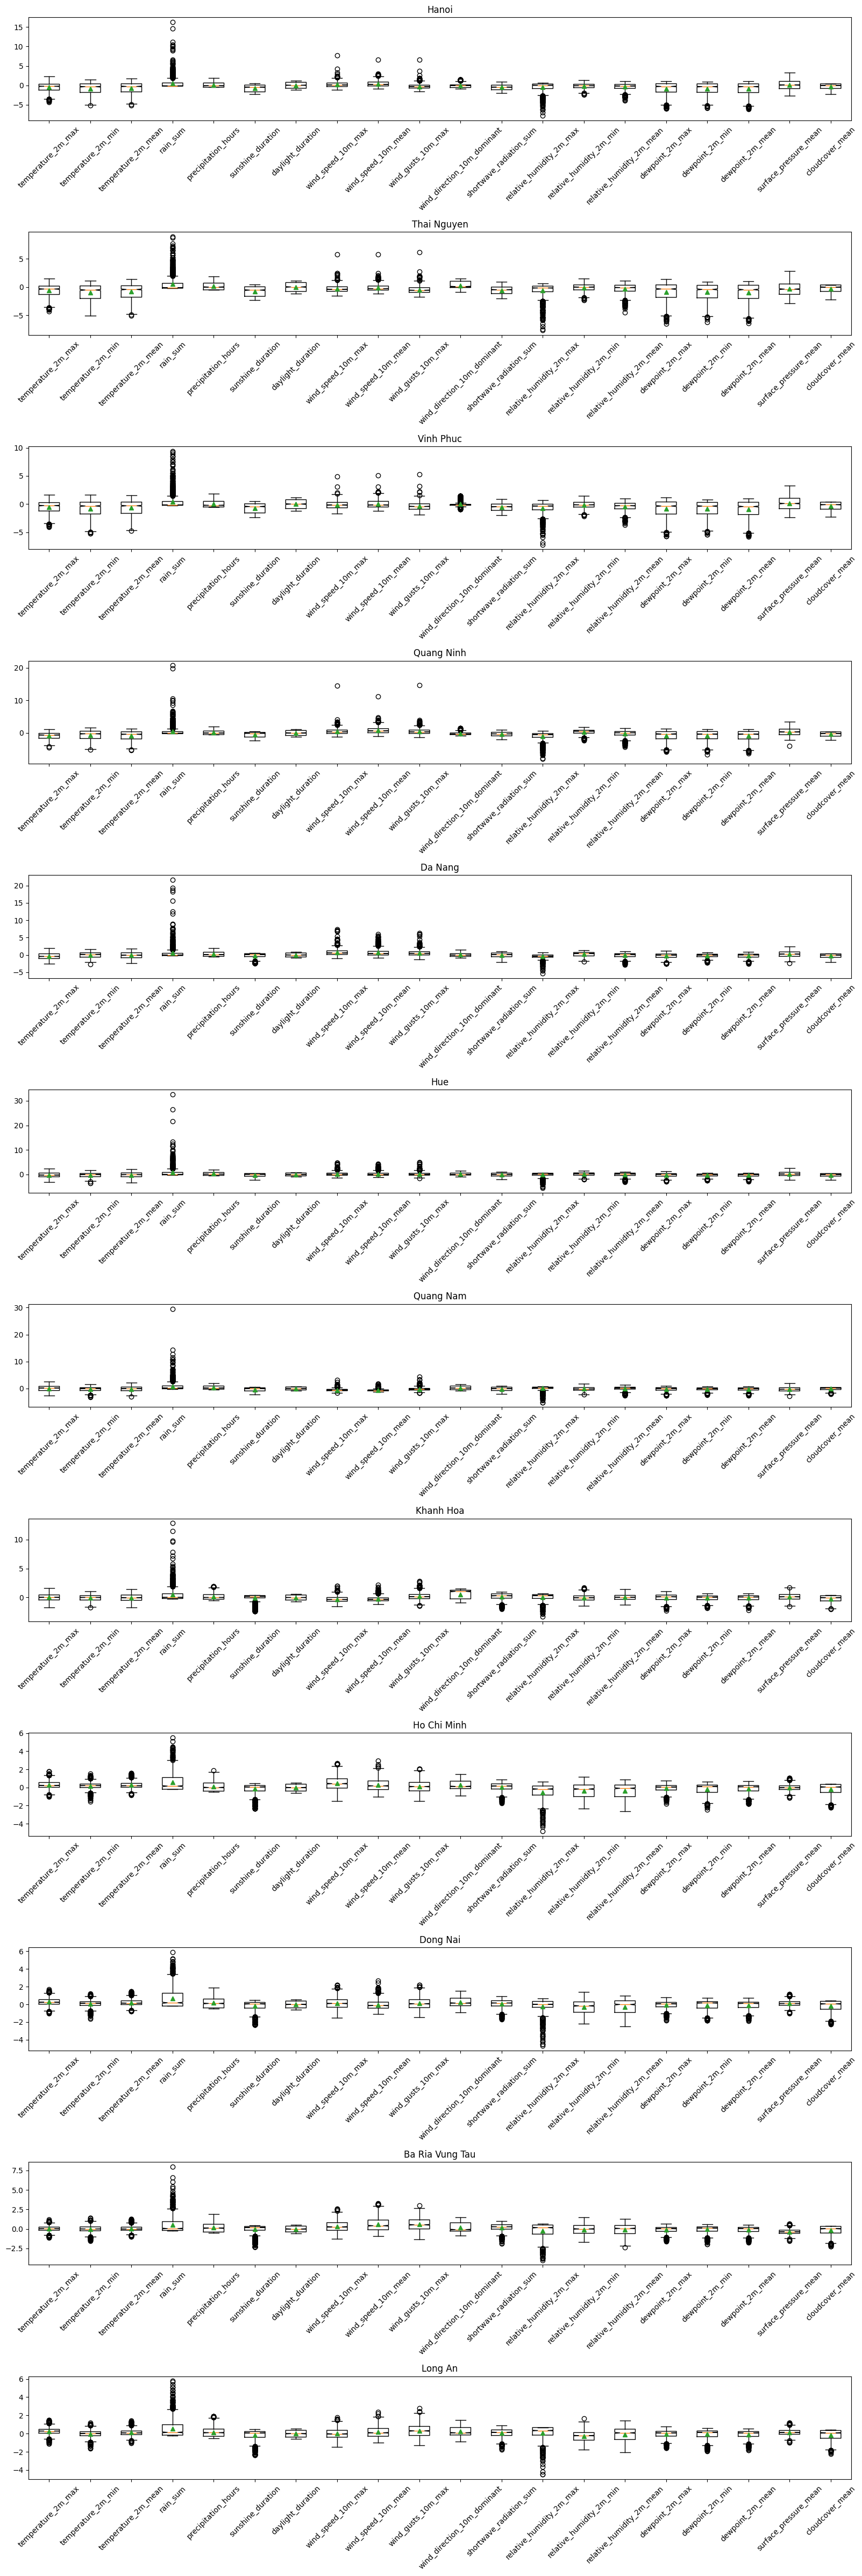

In [19]:
plt.figure(figsize=(16, 48))
cities = df_scaler['city'].unique()
for index, city in enumerate(cities):
    plt.subplot(len(cities), 1, index + 1)
    data = df_scaler[df_scaler['city'] == city][cols_num]
    plt.boxplot([data[c] for c in cols_num], tick_labels=cols_num, showmeans=True, notch=True)
    plt.title(city)
    plt.xticks(rotation=45)
    plt.tight_layout()

2.2. Rolling IQR

In [20]:

outlier = ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
           'rain_sum', 'precipitation_hours', 'sunshine_duration',
           'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_gusts_10m_max', 'shortwave_radiation_sum',
           'relative_humidity_2m_max', 'relative_humidity_2m_min', 'relative_humidity_2m_mean',
           'dewpoint_2m_max', 'dewpoint_2m_min', 'dewpoint_2m_mean',
           'surface_pressure_mean', 'cloudcover_mean']

df_iqr = df_scaler.copy()

def Sliding(data, window_size=7):
    roller = data.rolling(window=window_size, min_periods=1)
    q1 = roller.quantile(0.25)
    q3 = roller.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data_anomaly = data[(data < lower_bound) | (data > upper_bound)]
    return data_anomaly, data.clip(lower=lower_bound, upper=upper_bound)

anomaly_dict = {}
for col in outlier:
    col_anomalies_list = []
    cities = df_iqr['city'].unique()
    for city in cities:
        mask = df_iqr['city'] == city
        city_data = df_iqr.loc[mask, col]
        anomalies, handled_data = Sliding(city_data, window_size=7)   
        df_iqr.loc[mask, col] = handled_data
        if not anomalies.empty:
            col_anomalies_list.append(anomalies)
    if col_anomalies_list:
        anomaly_dict[col] = pd.concat(col_anomalies_list).sort_index()
    else:
        anomaly_dict[col] = pd.Series(dtype=float) # Trống nếu không có anomaly nào

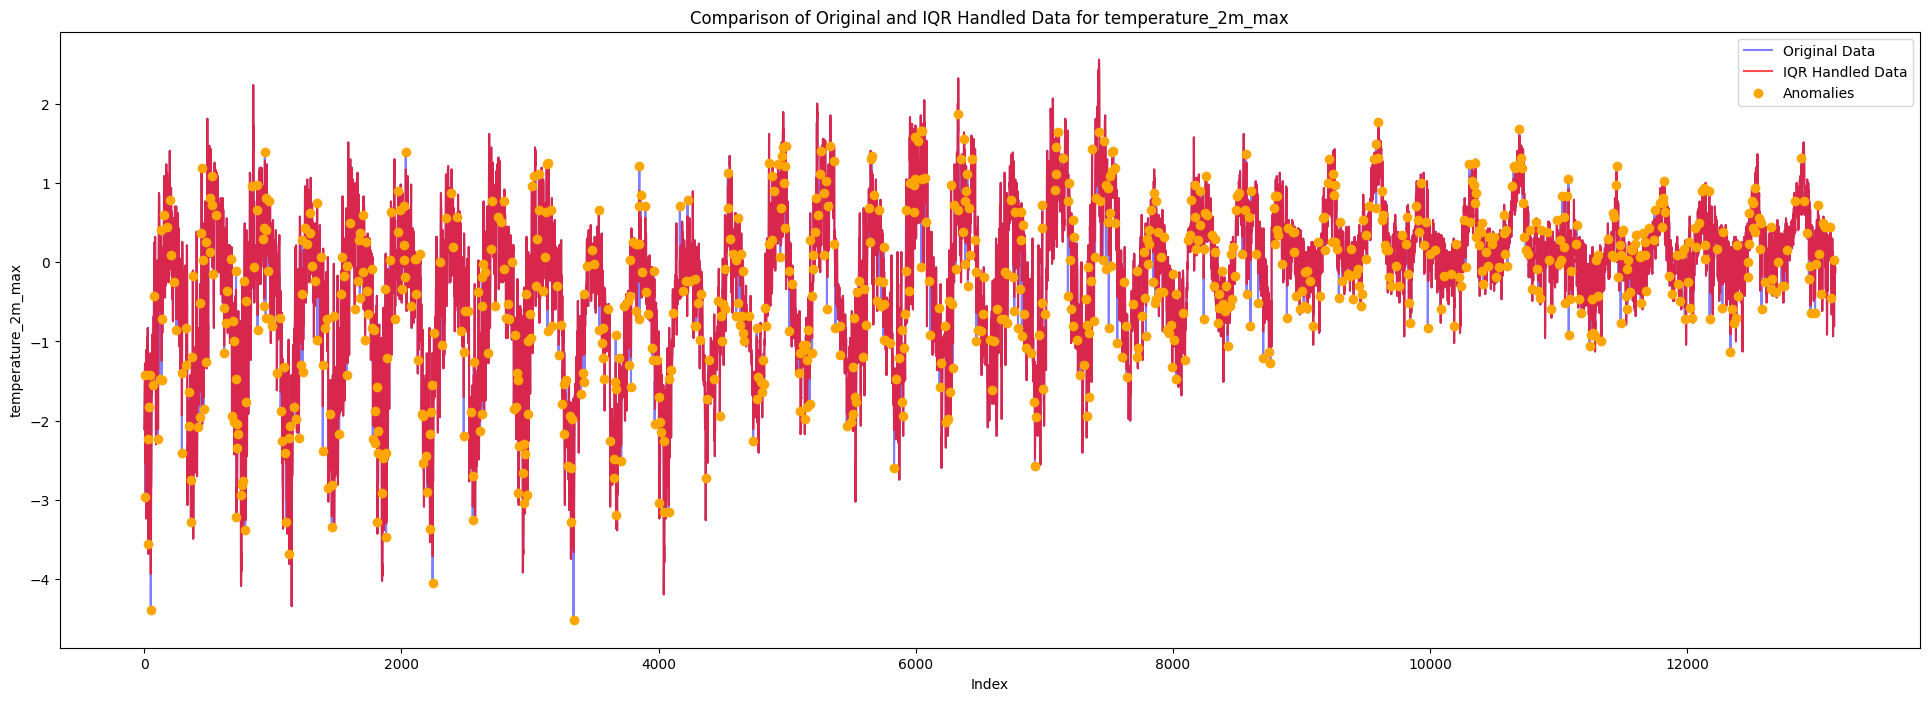

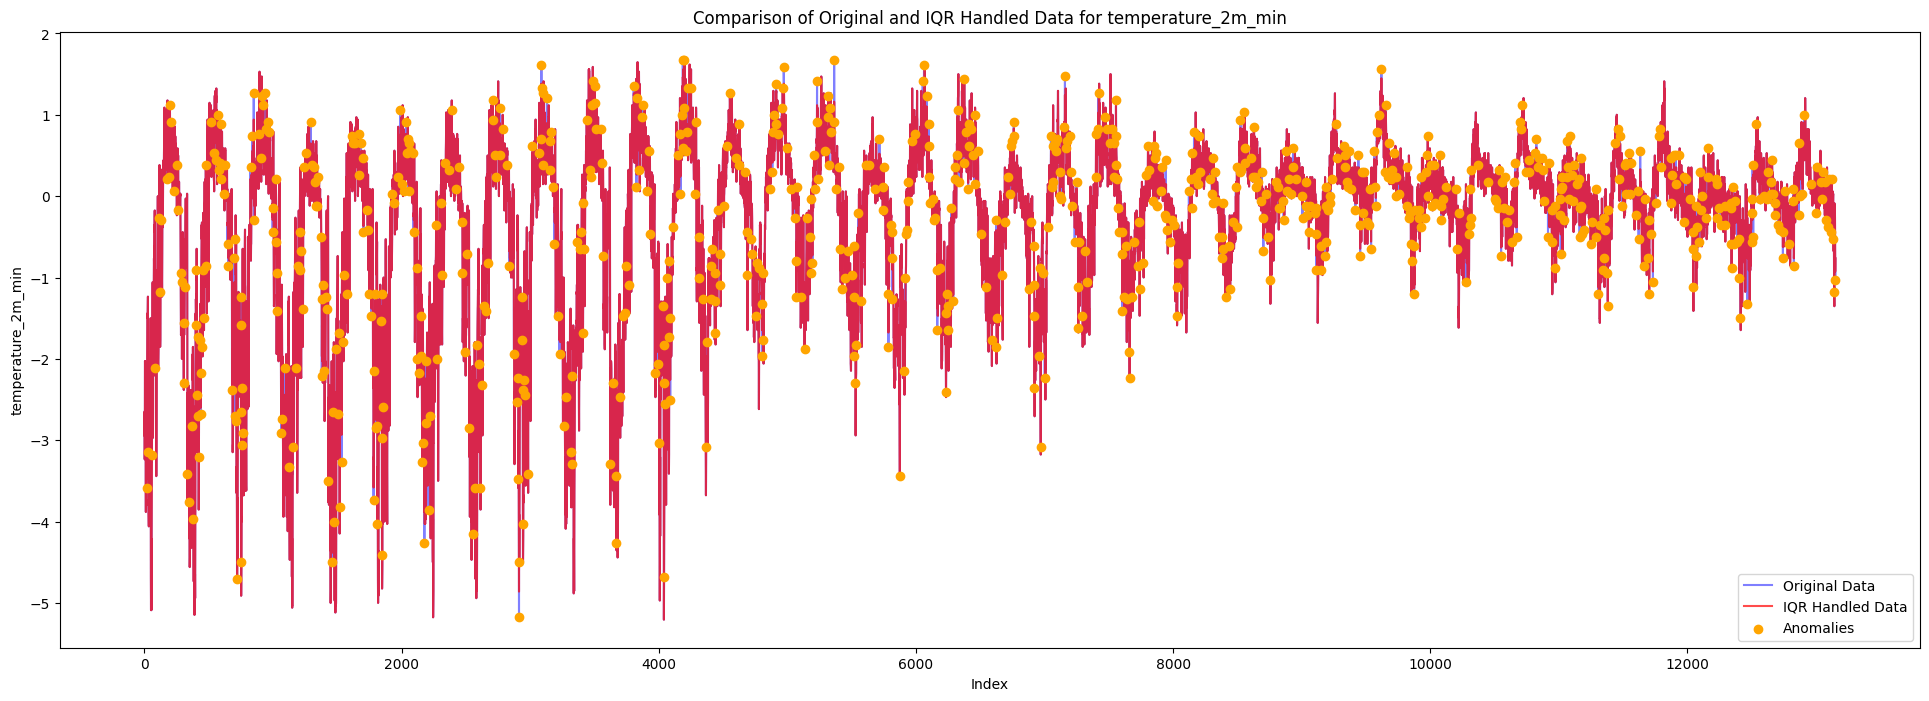

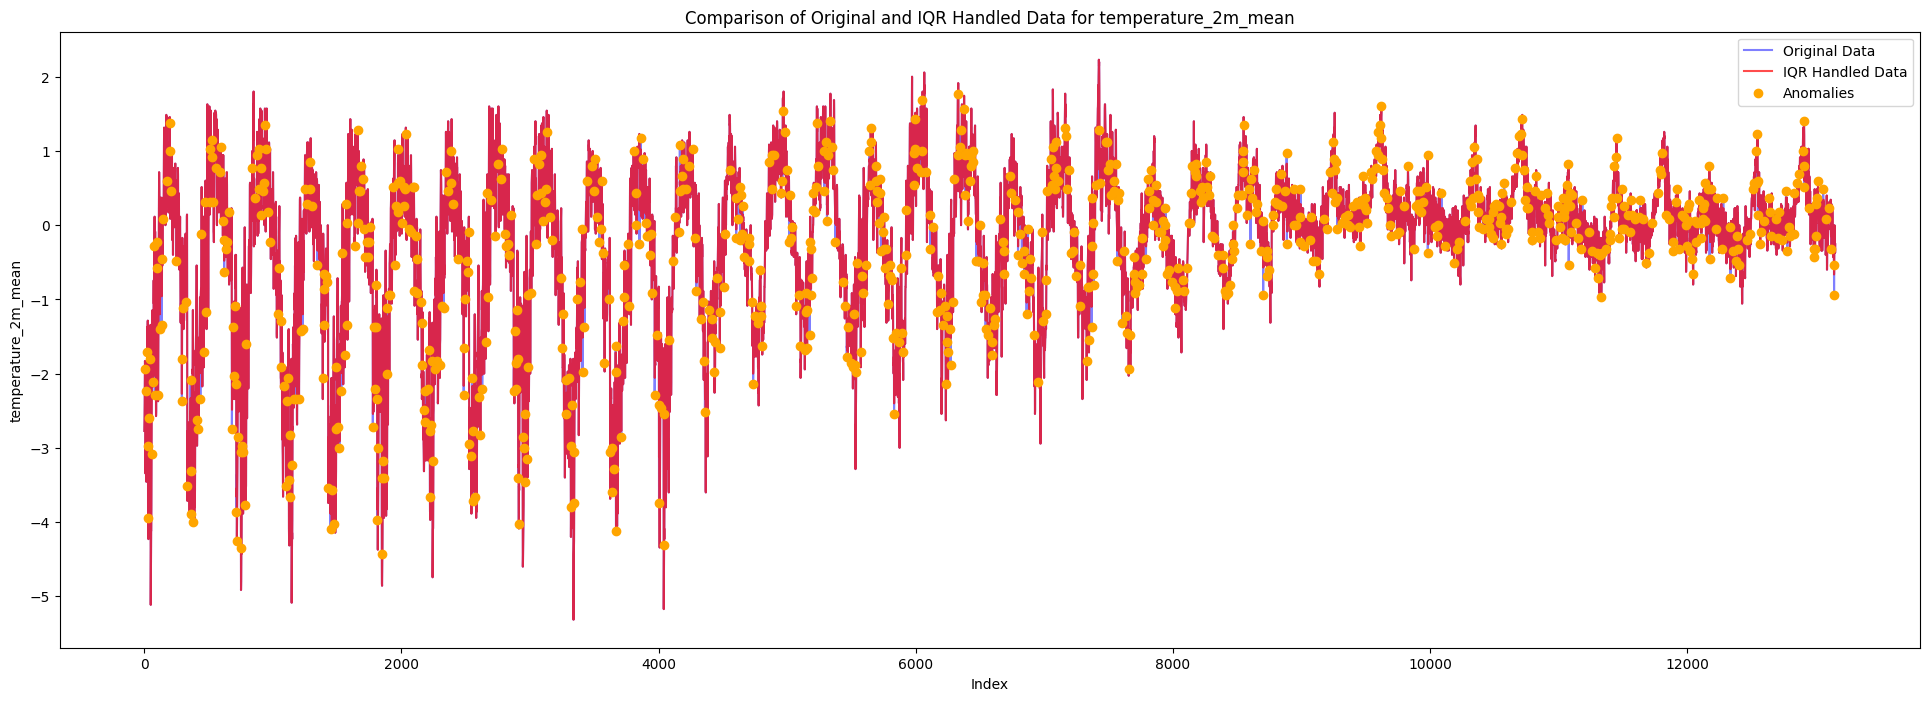

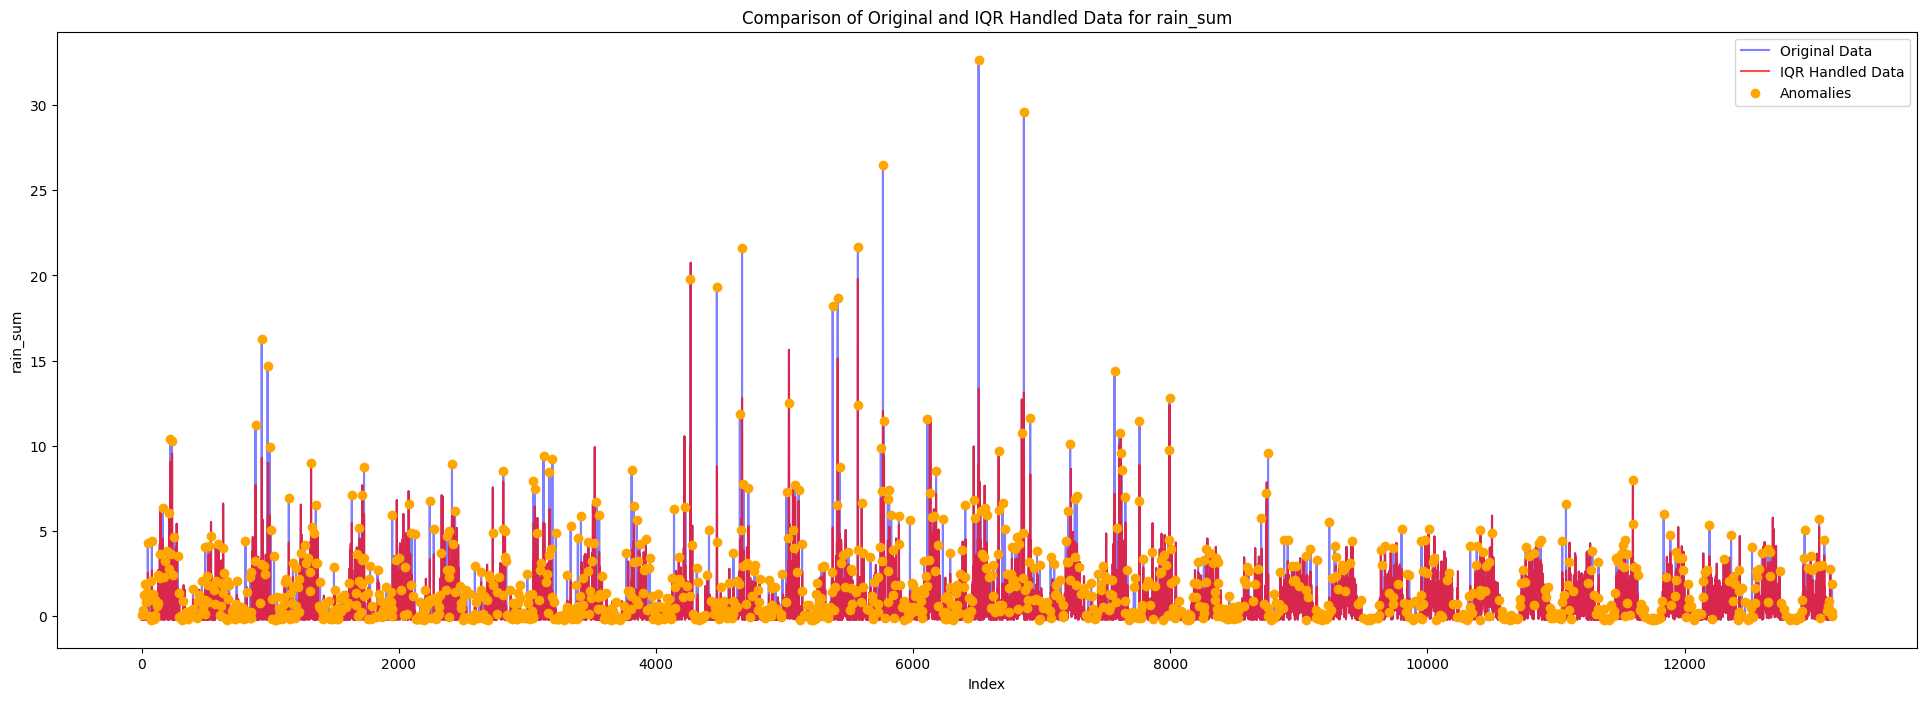

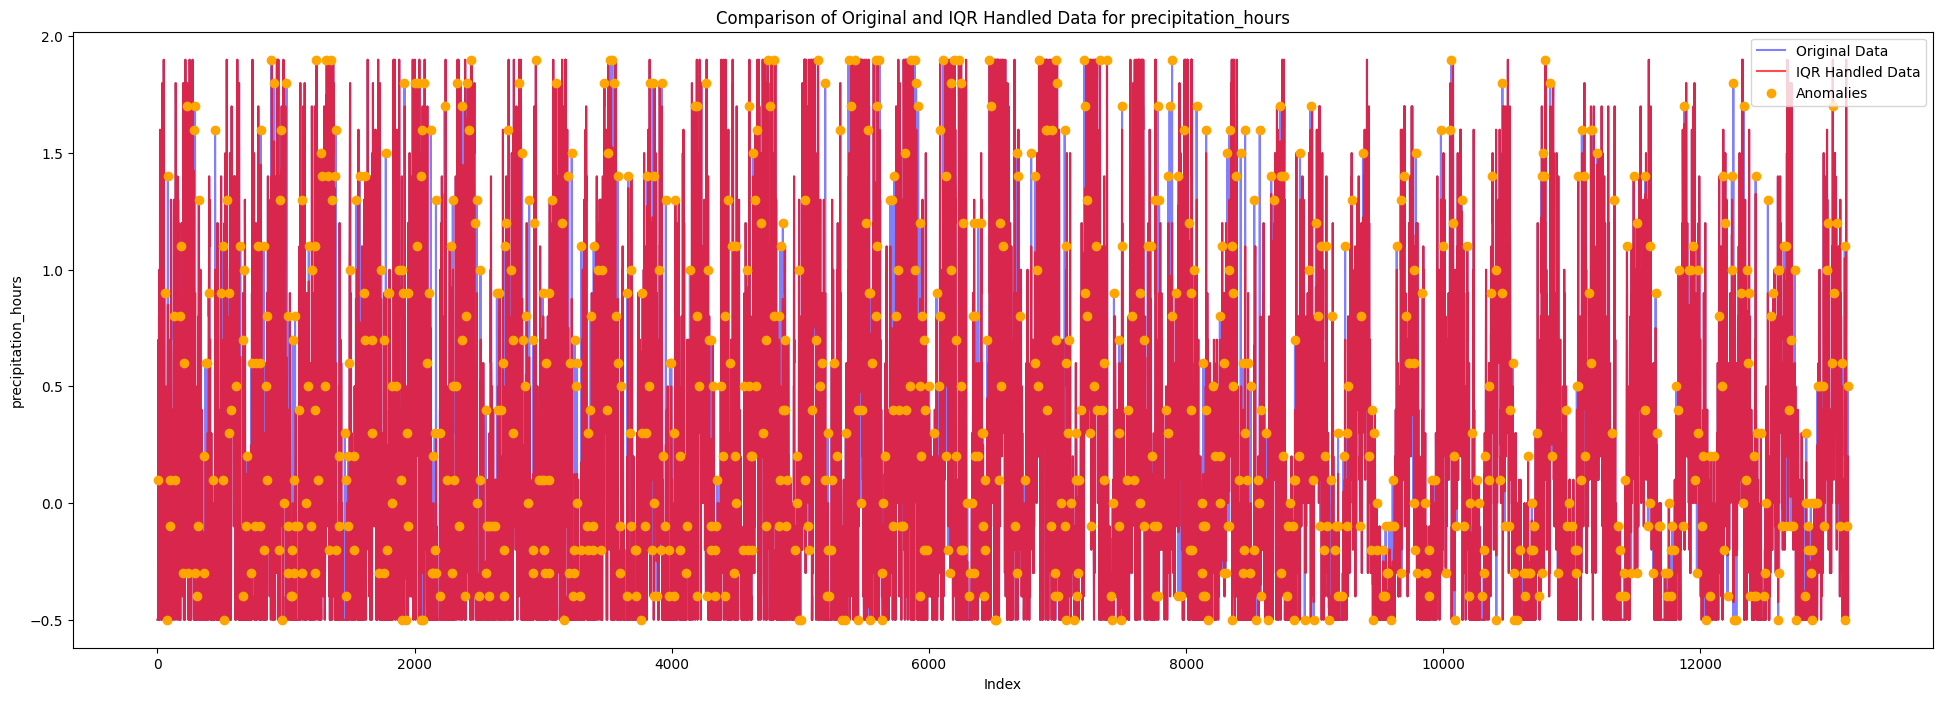

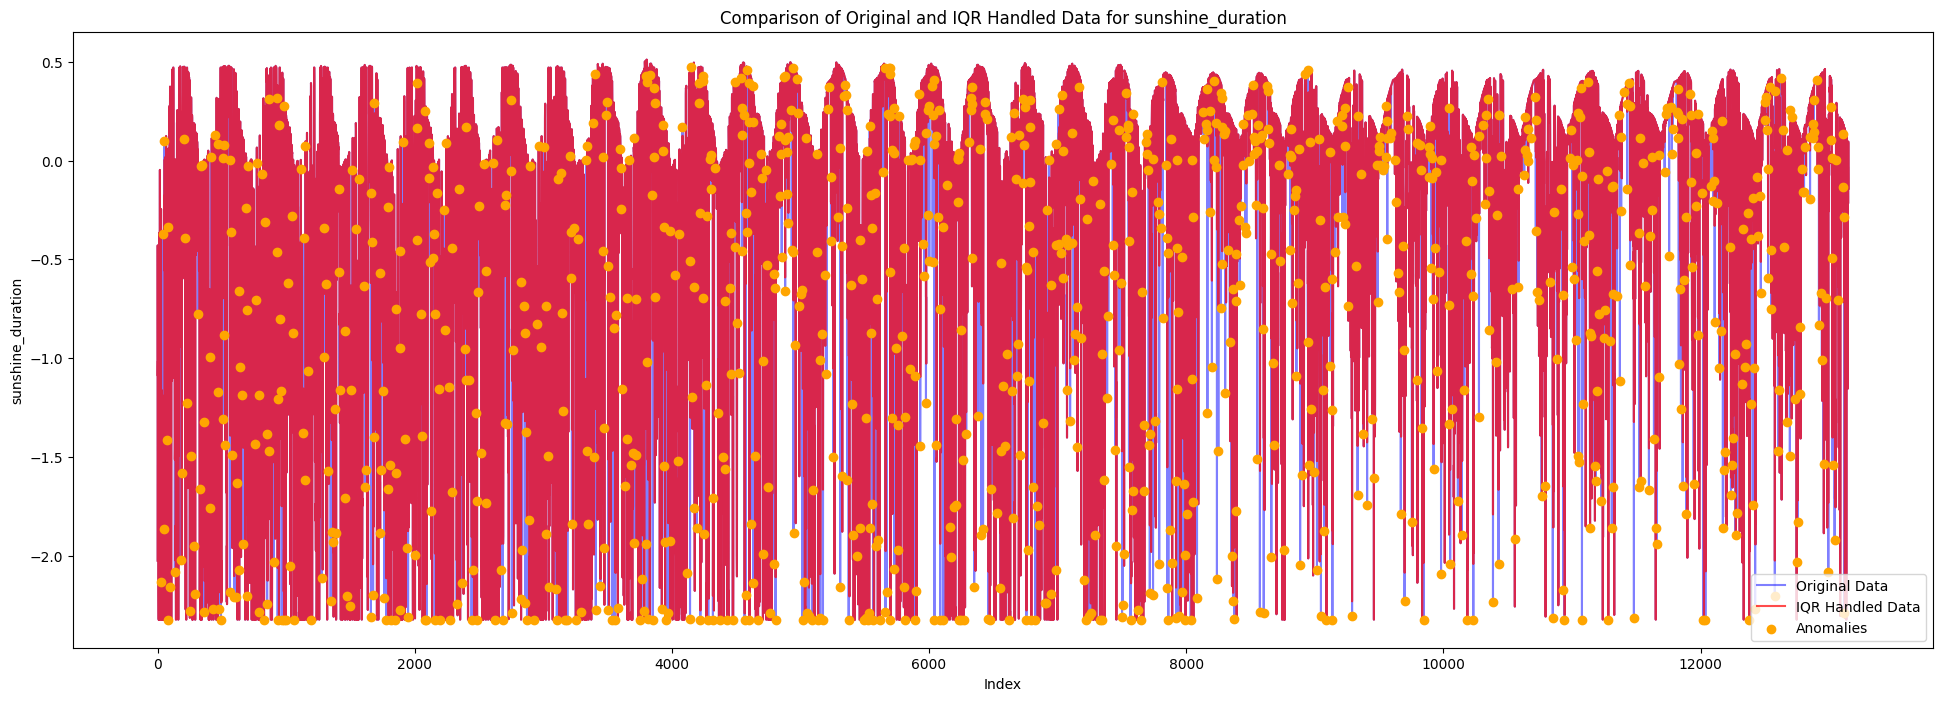

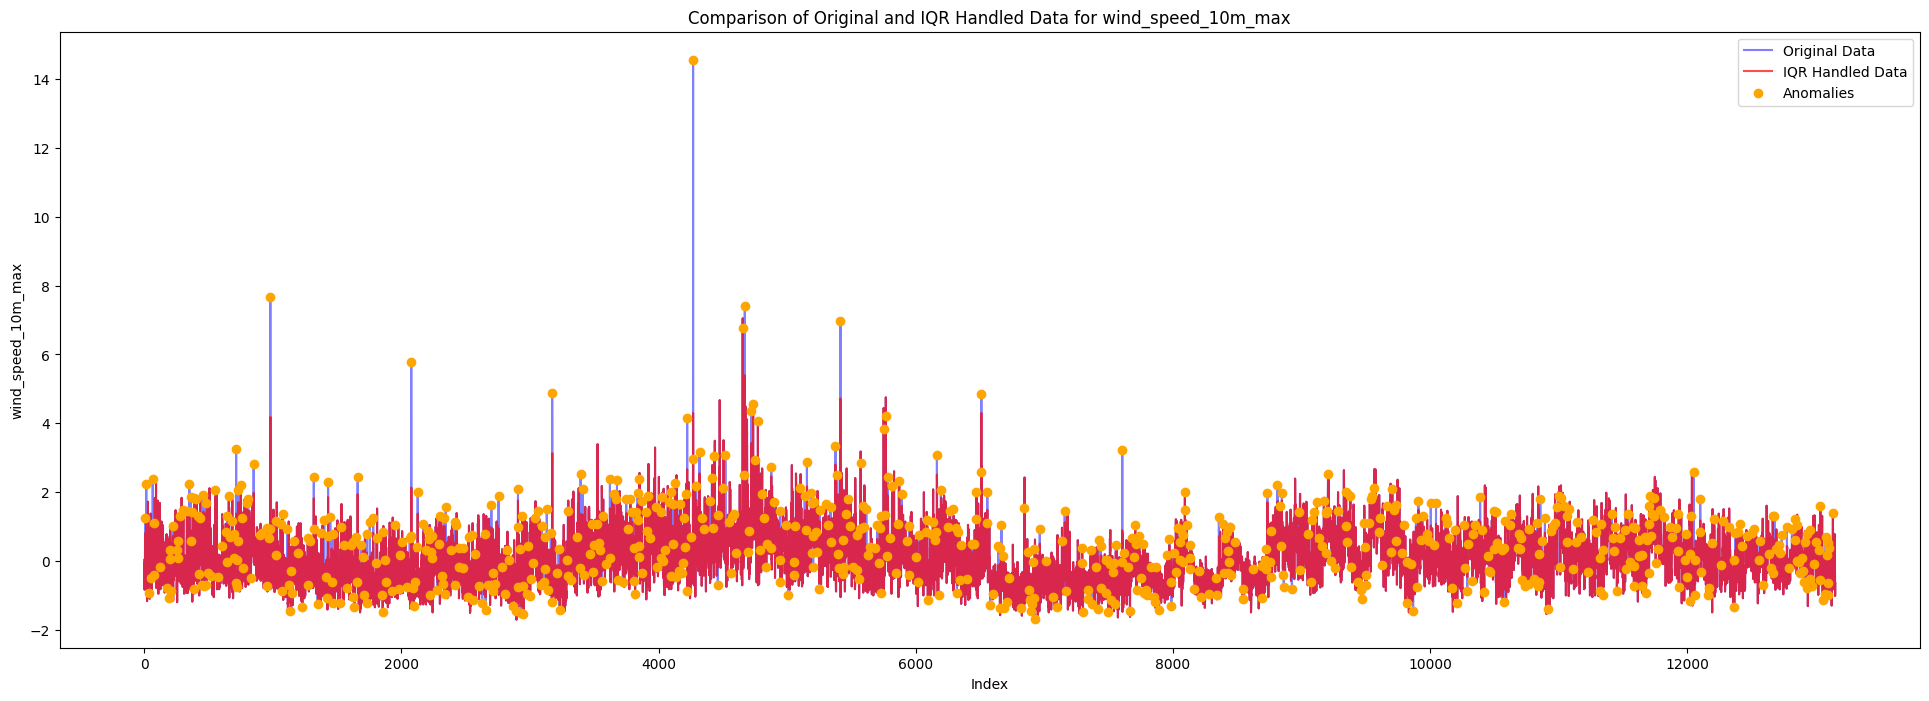

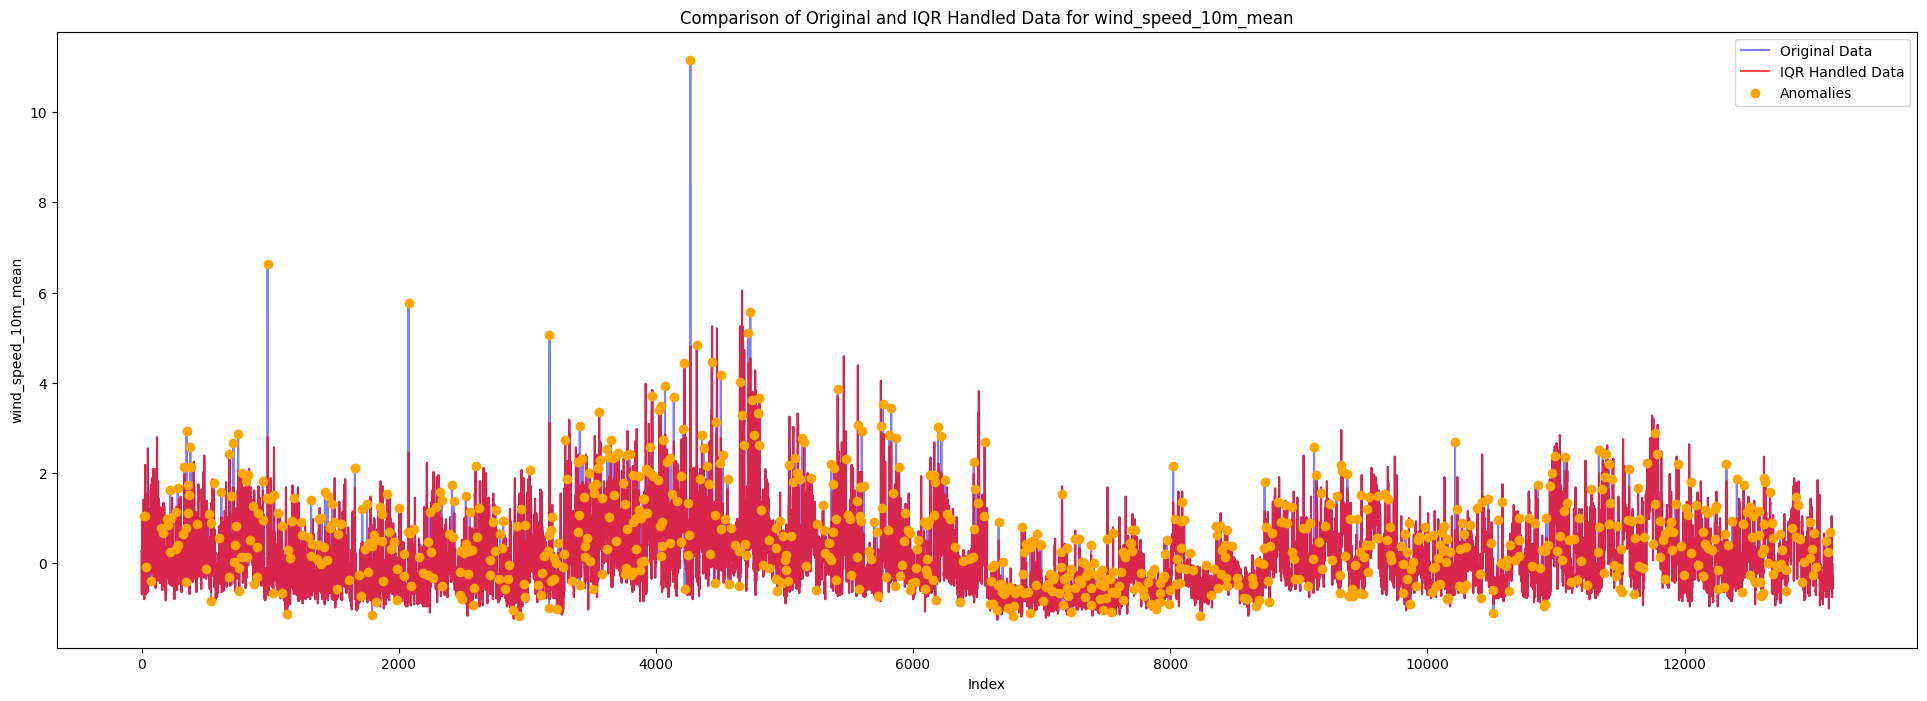

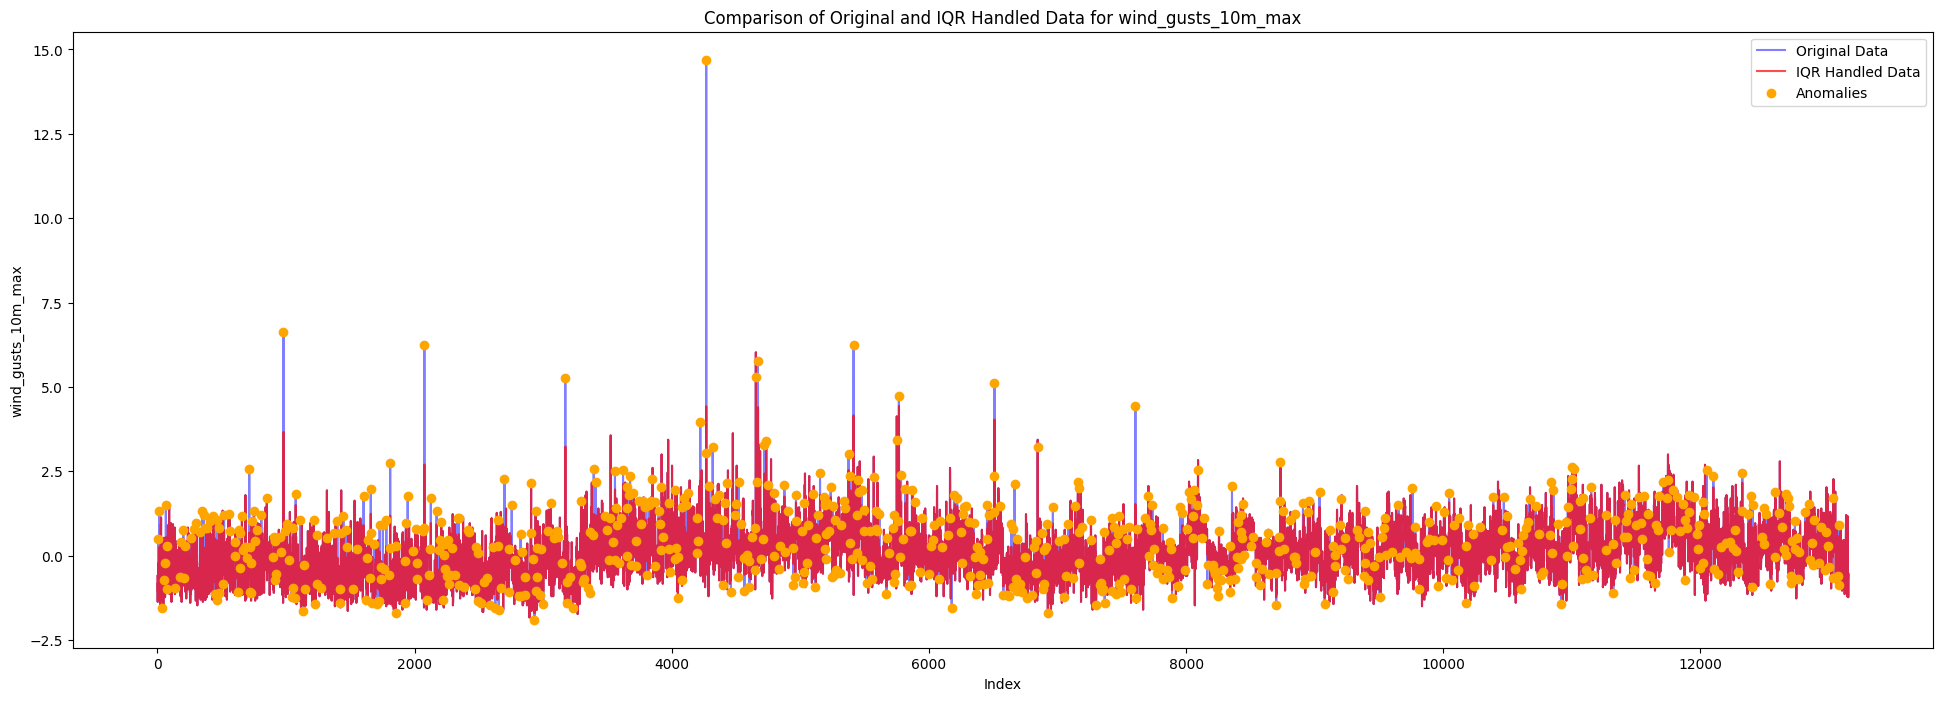

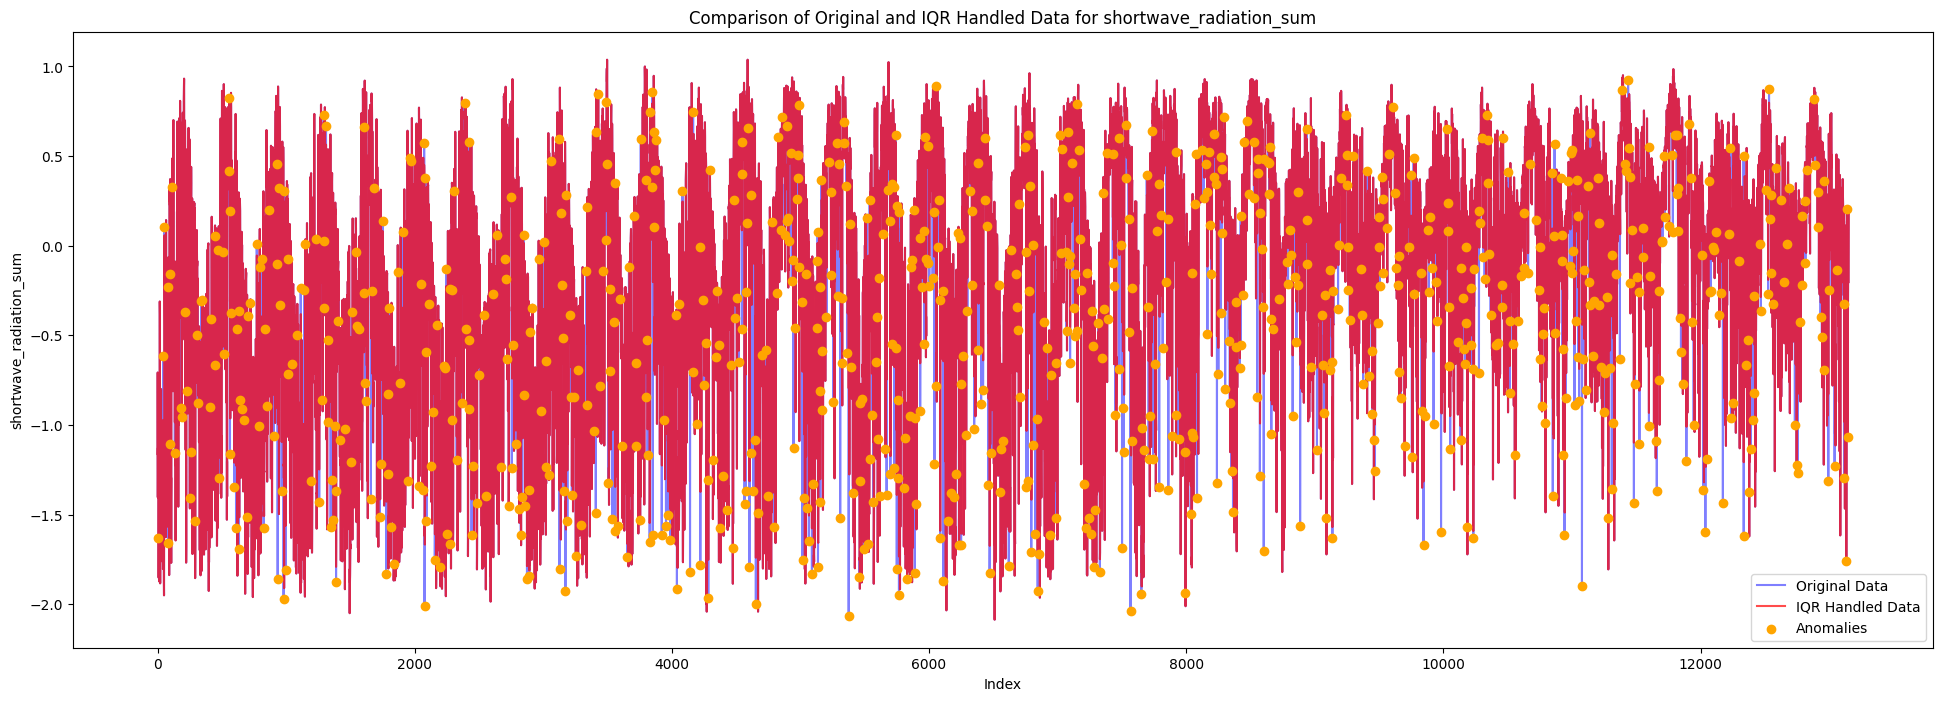

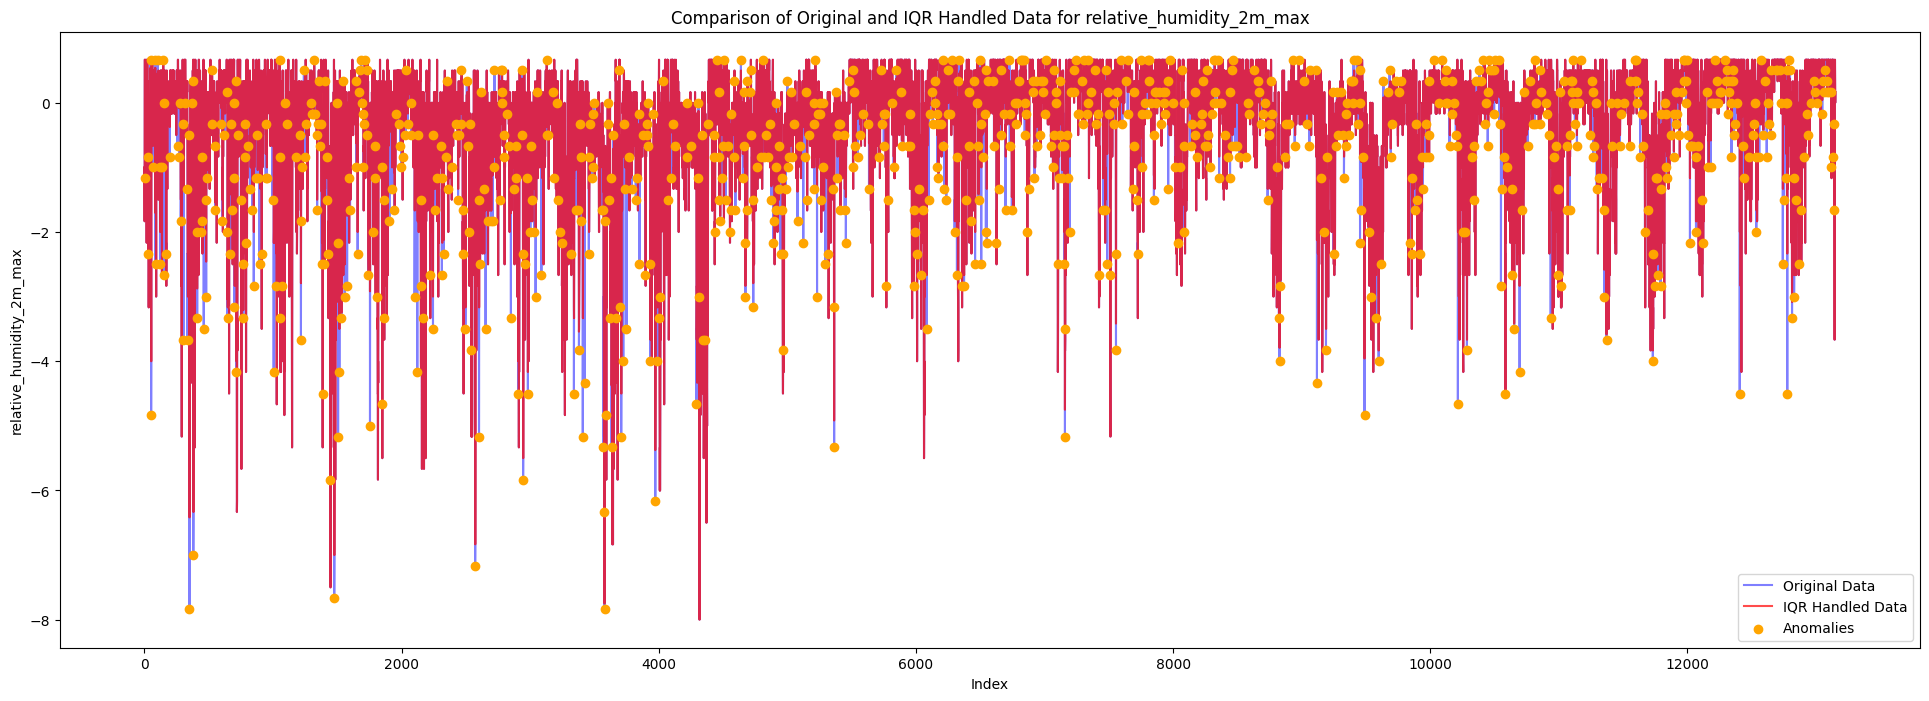

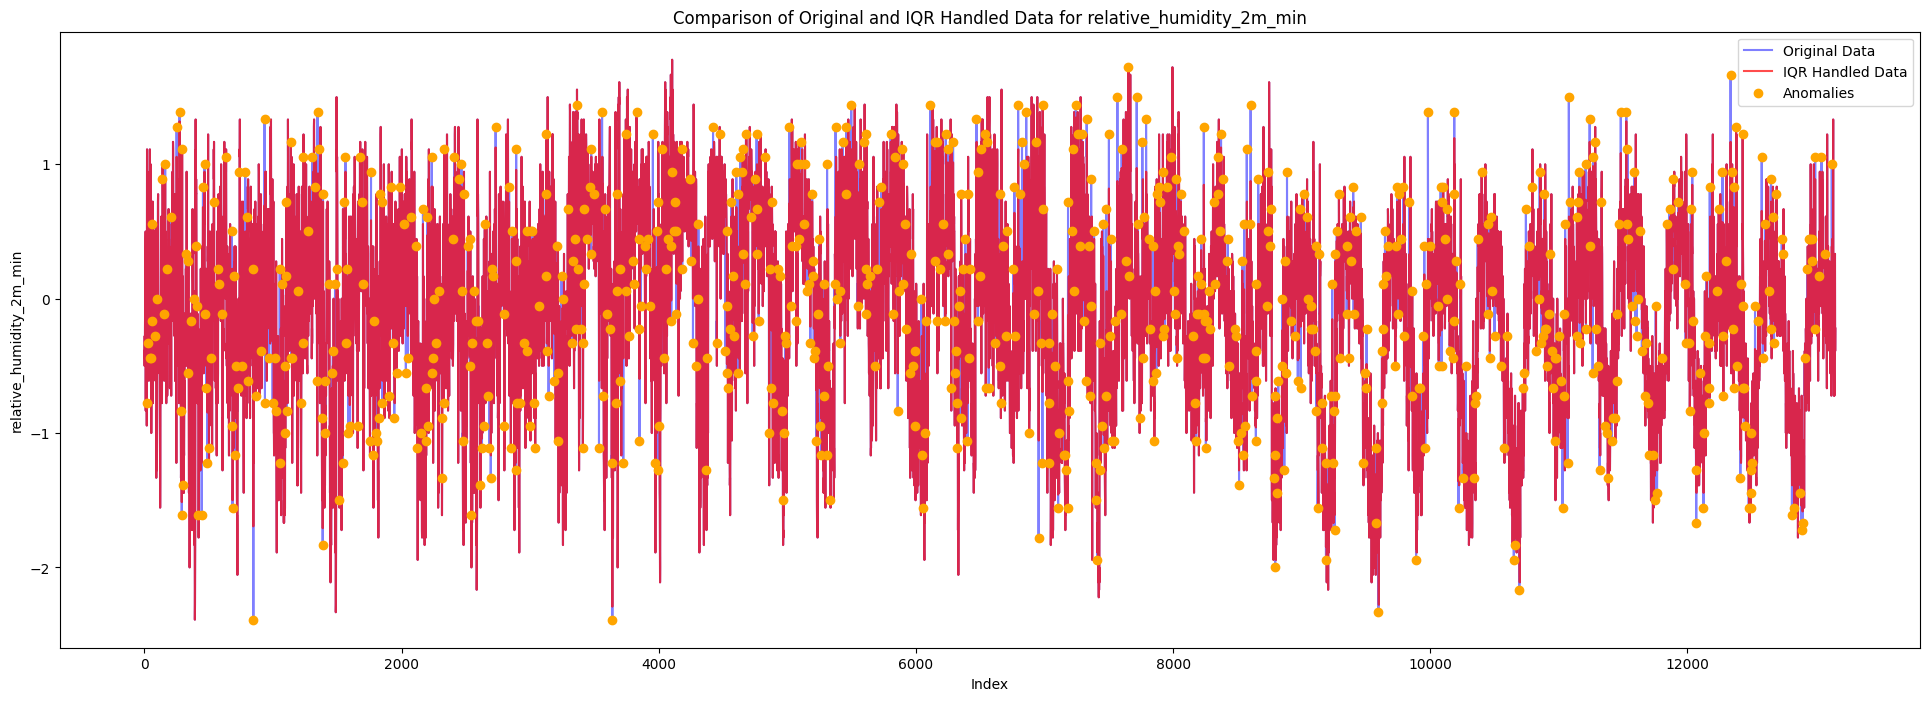

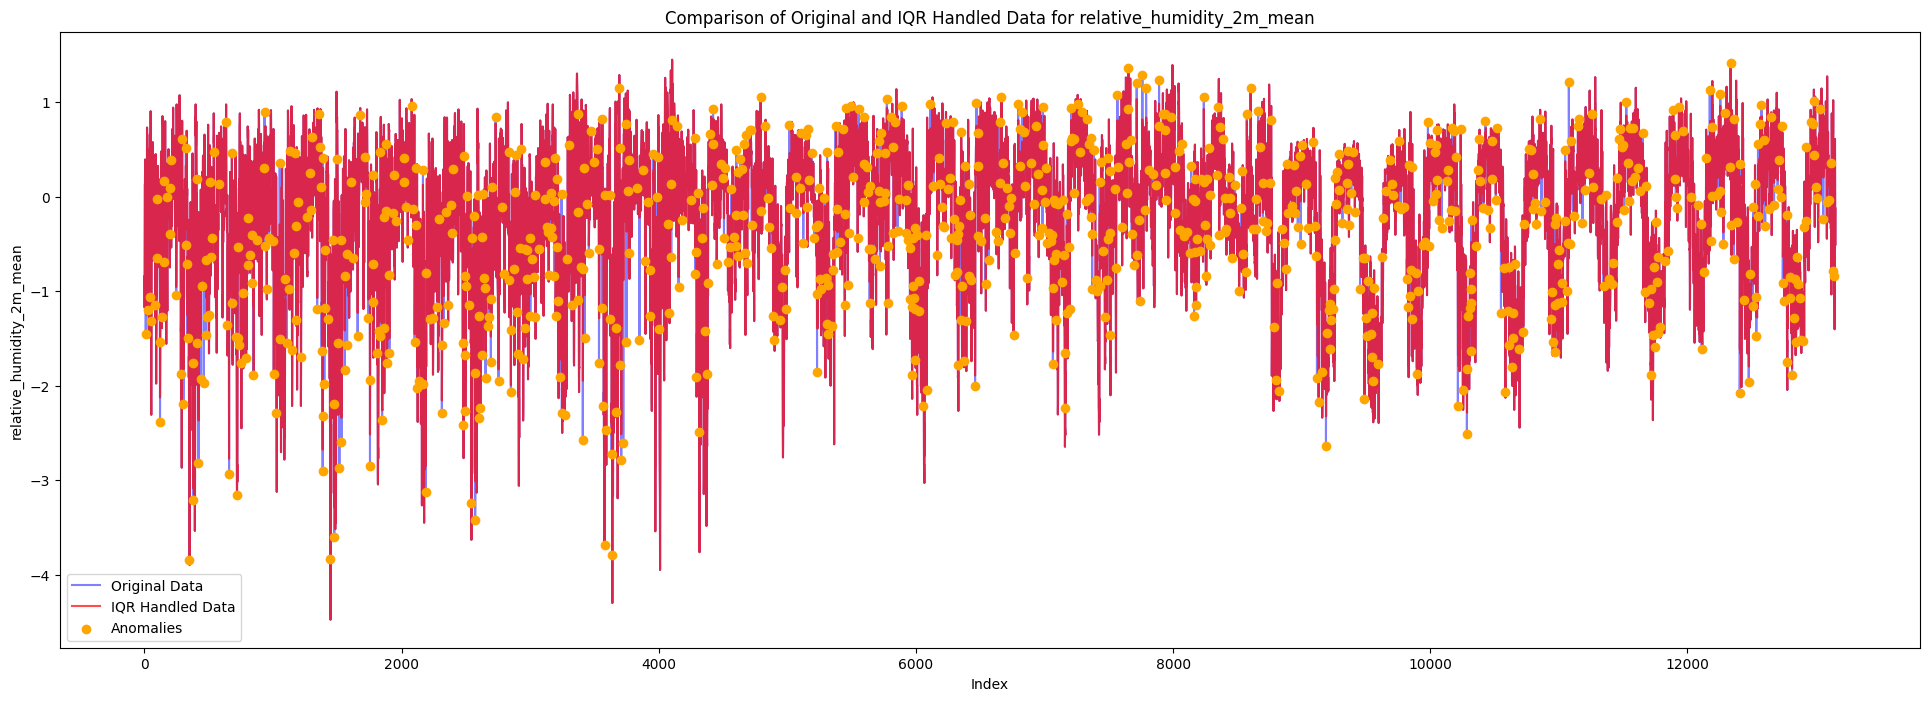

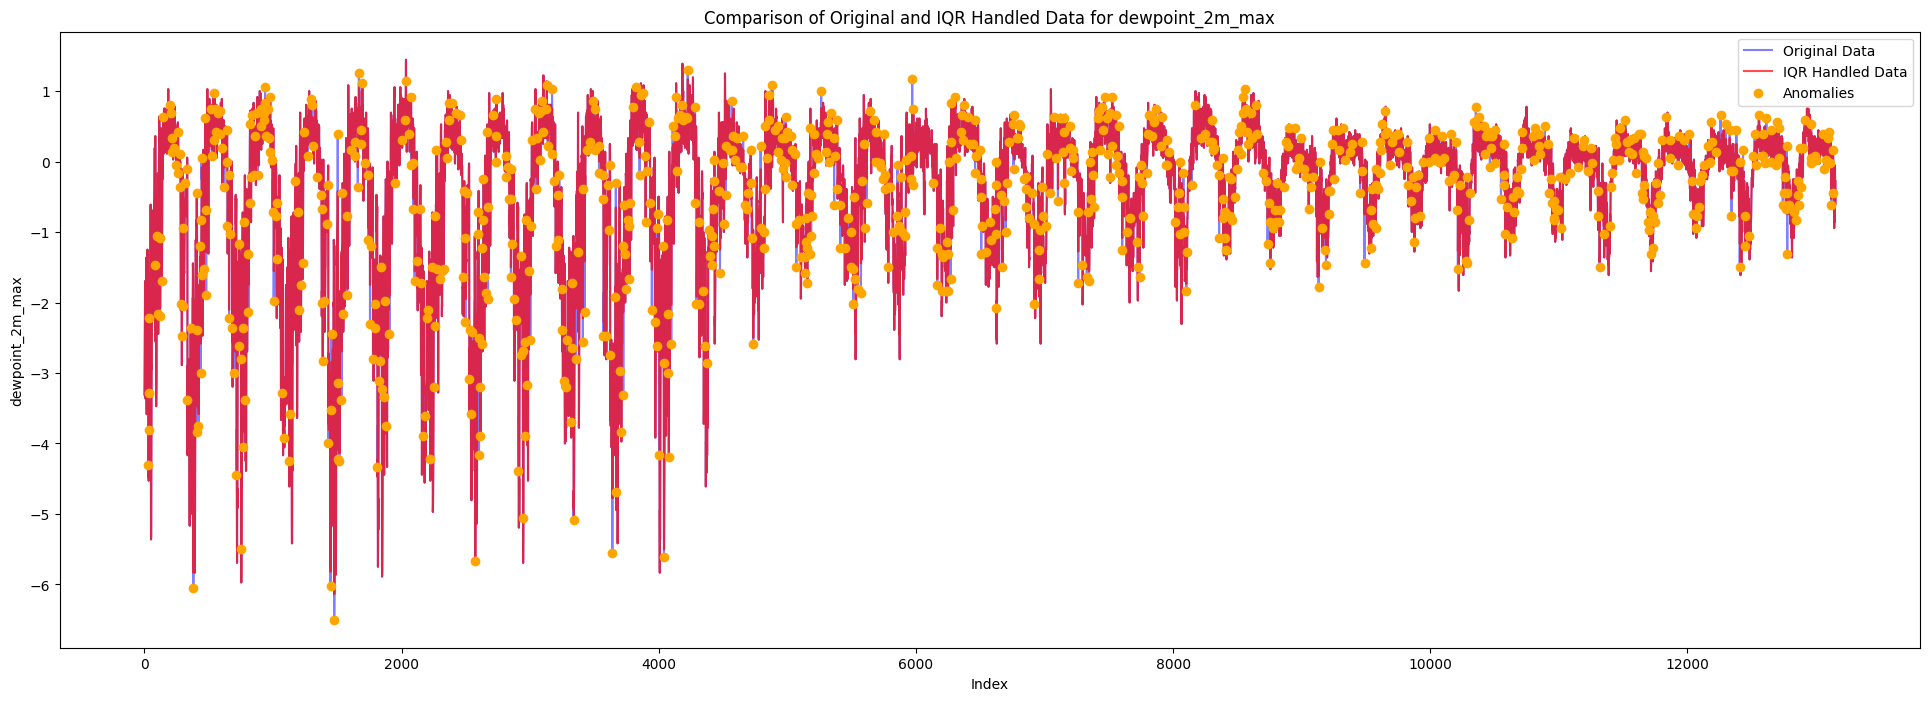

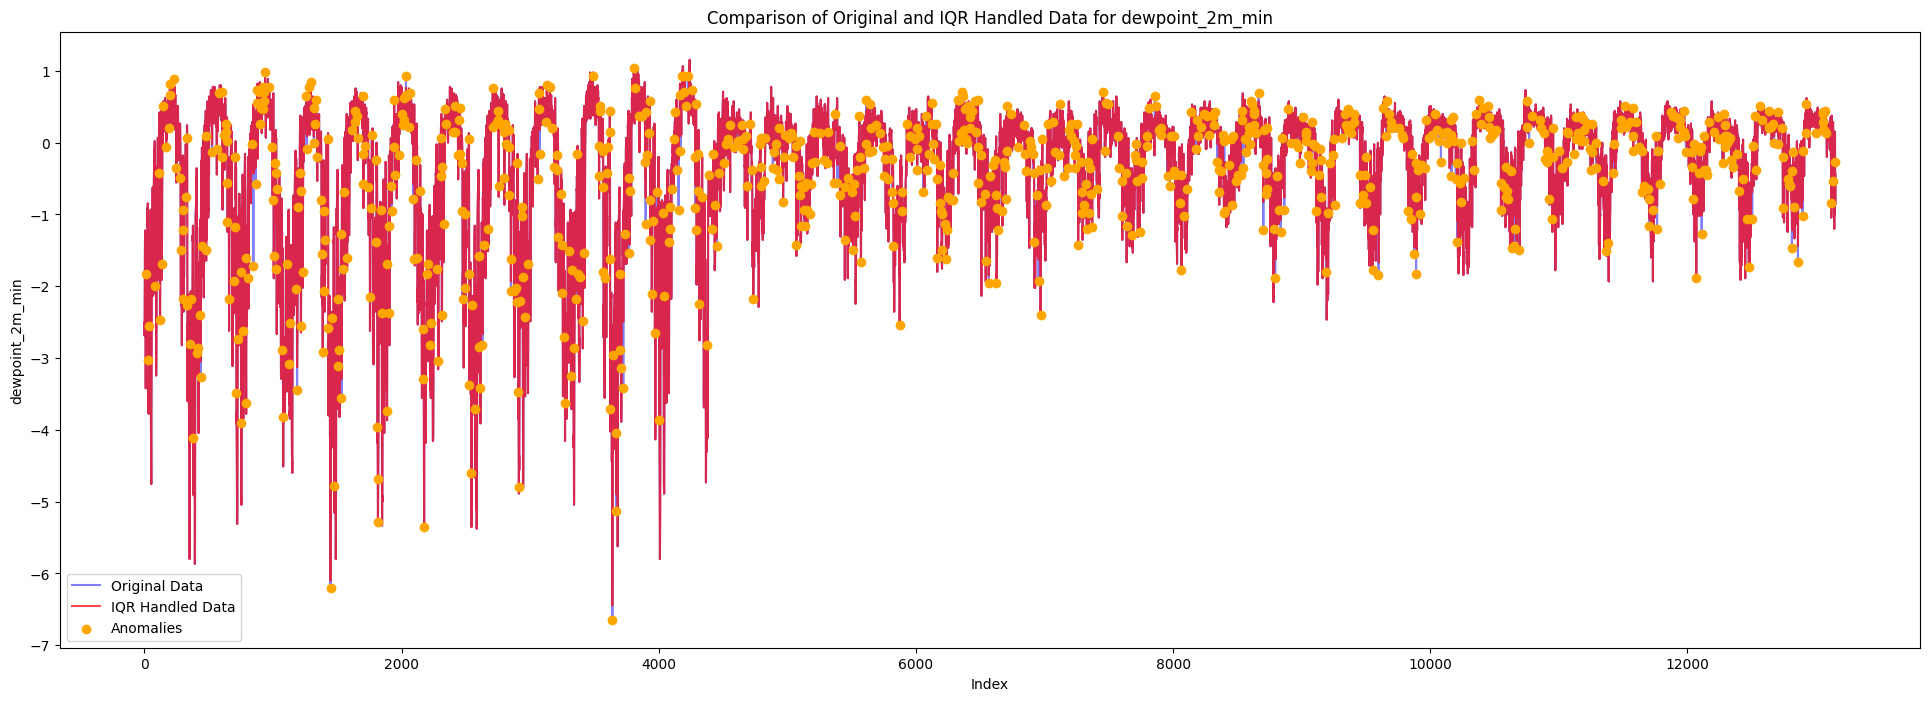

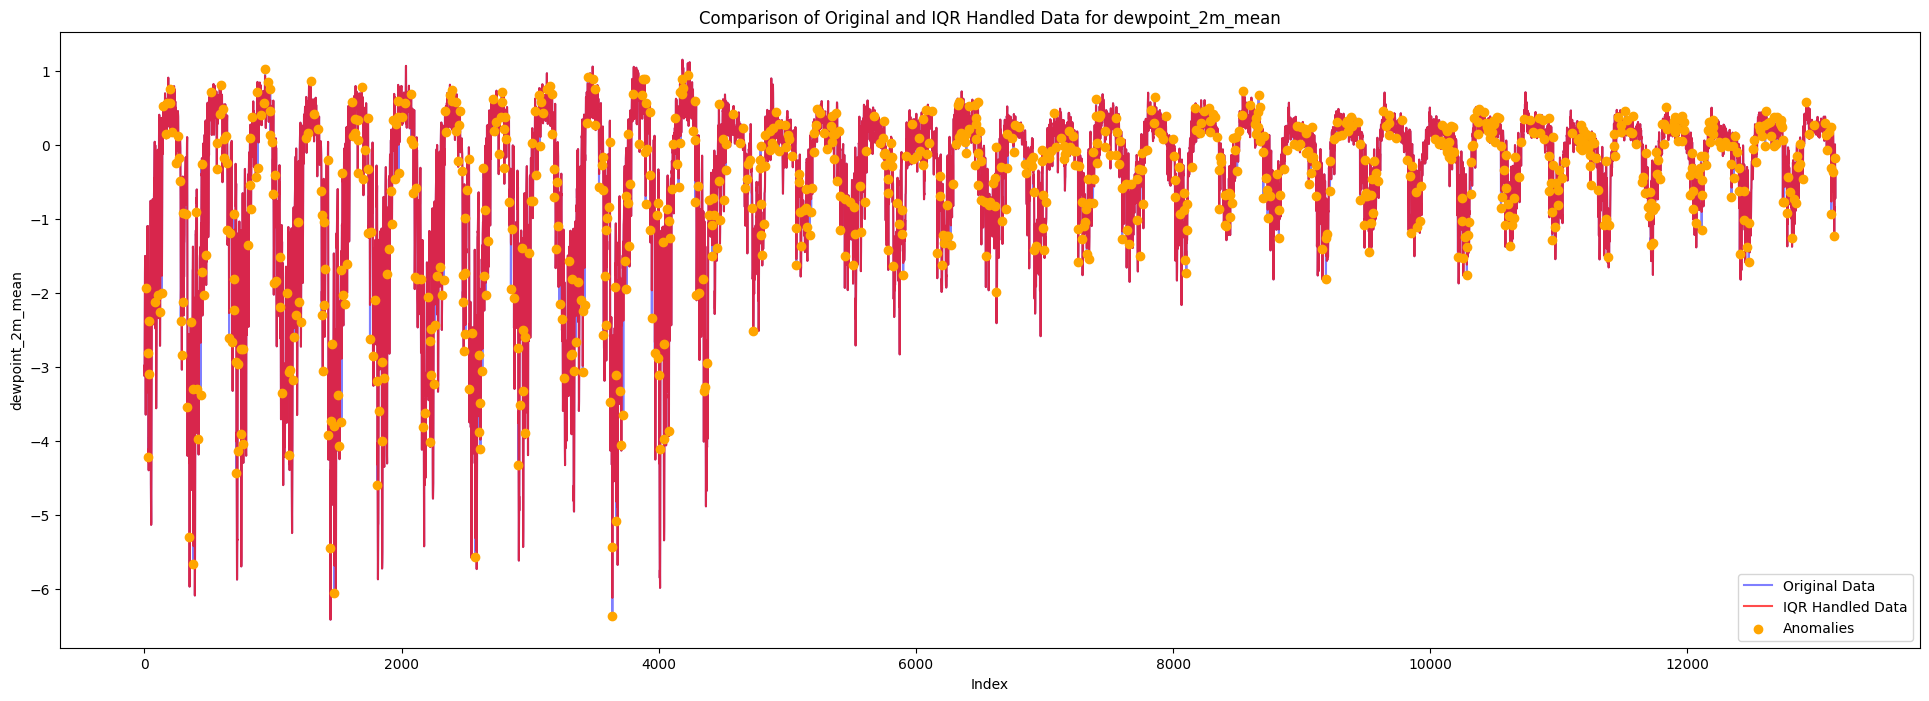

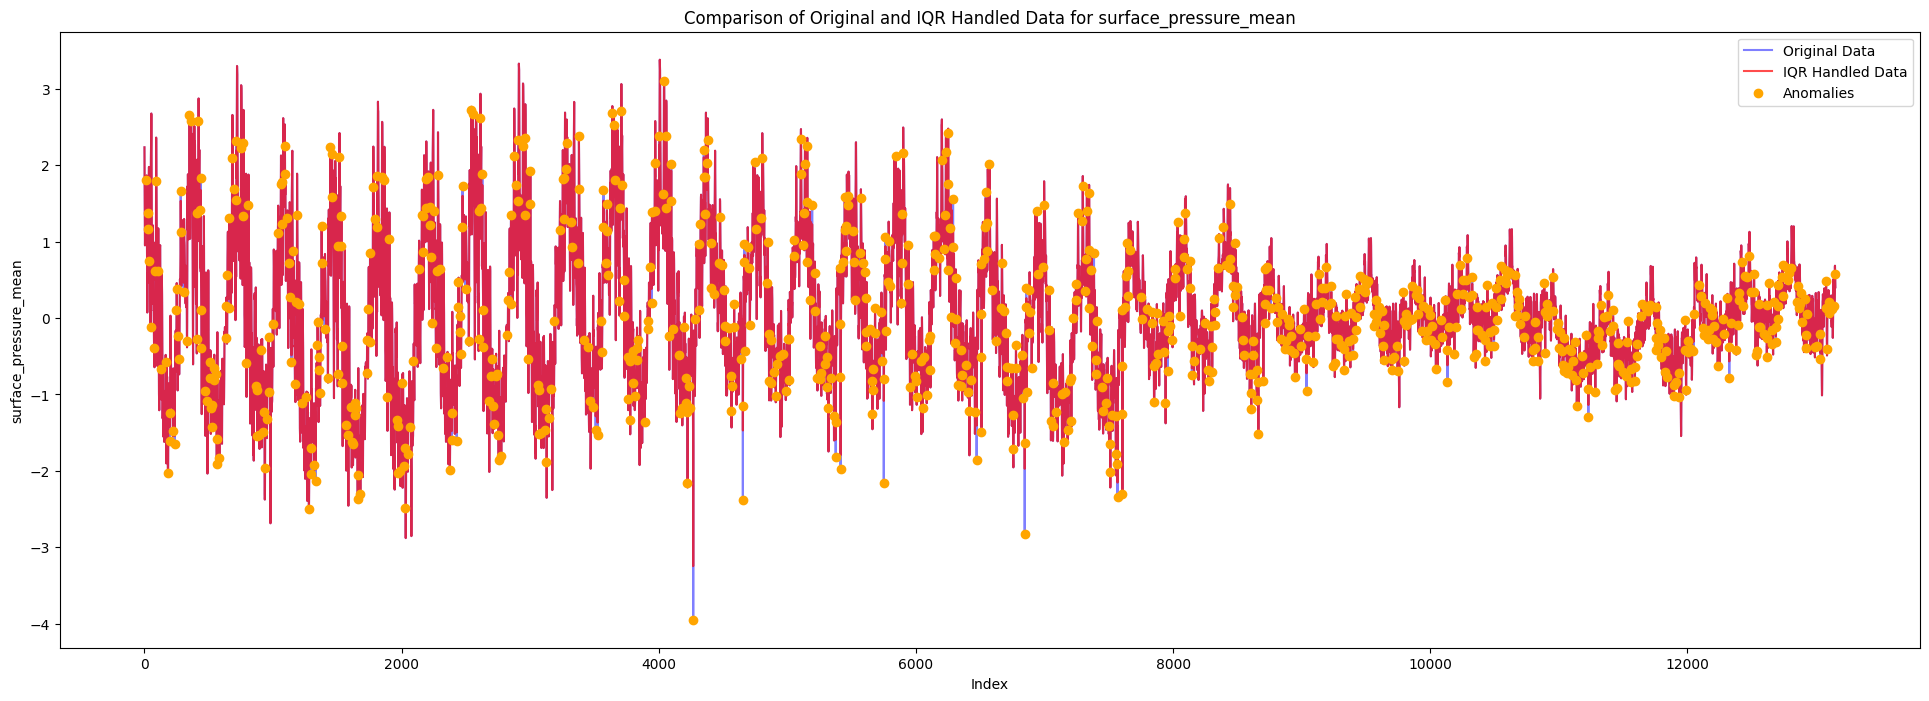

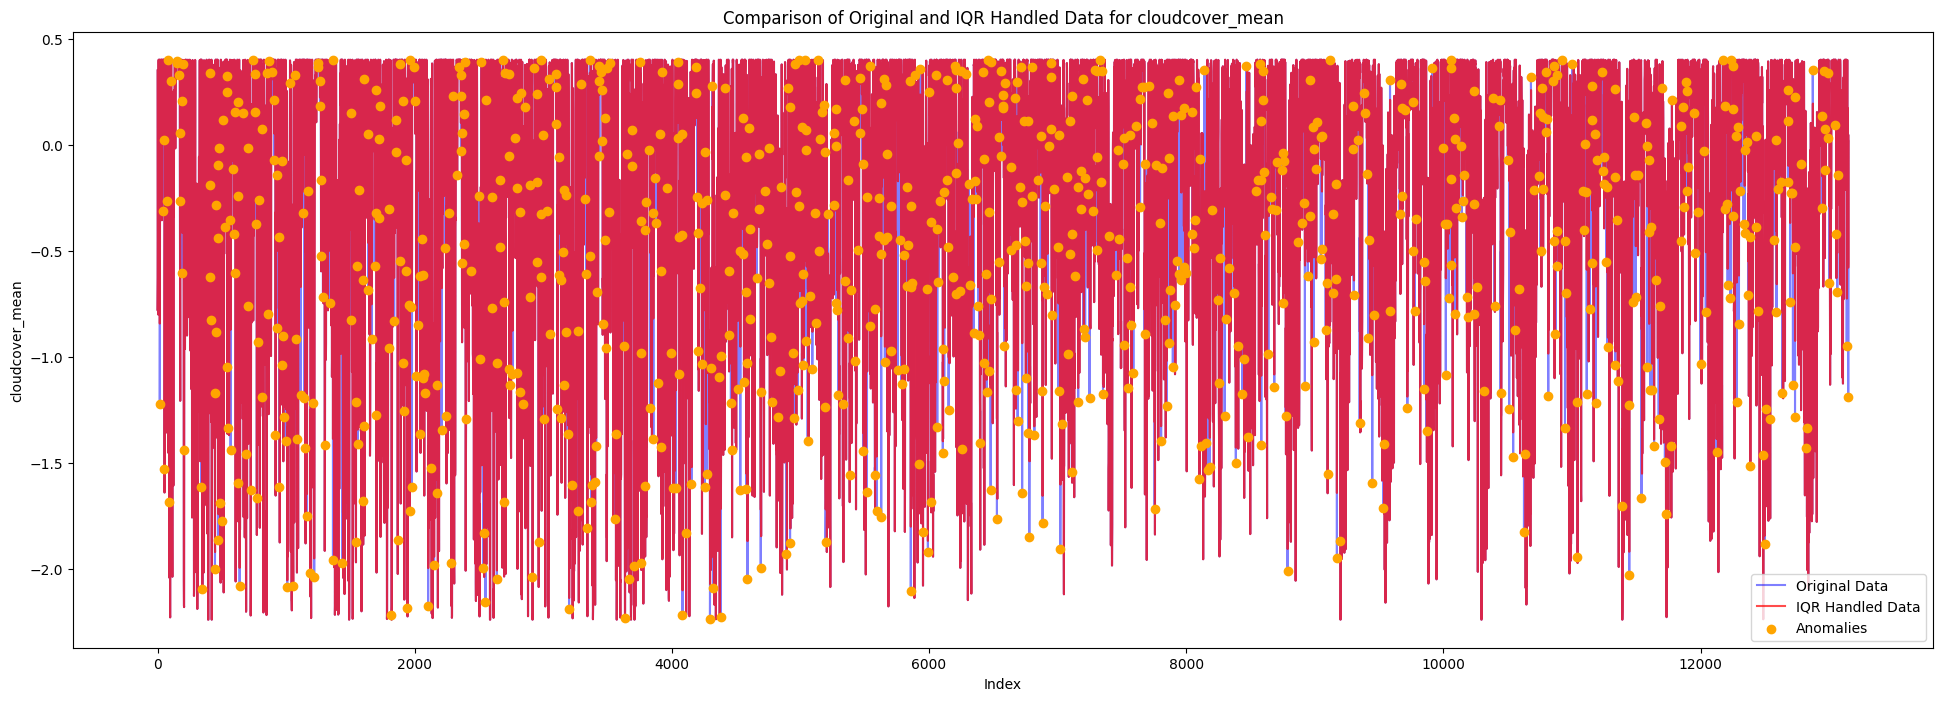

In [21]:
def Line_IQR_Change(old_data, new_data, col_name):
    plt.figure(figsize=(24, 8))
    plt.plot(old_data.index, old_data.values, label='Original Data', color='blue', alpha=0.5)
    plt.plot(new_data.index, new_data.values, label='IQR Handled Data', color='red', alpha=0.7)
    plt.scatter(anomaly_dict[col_name].index, anomaly_dict[col_name].values, color='orange', label='Anomalies', zorder=5)
    plt.title(f'Comparison of Original and IQR Handled Data for {col_name}')
    plt.xlabel('Index')
    plt.ylabel(col_name)
    plt.legend()
    plt.show()

for col in outlier:
    Line_IQR_Change(df_scaler[col], df_iqr[col], col)

### Feature Extraction

In [22]:
# Thay đổi các giá trị date thành ngày tháng năm
df_feature = df_iqr.copy()
df_feature['year'] = df_feature['date'].dt.year
df_feature['month'] = df_feature['date'].dt.month
df_feature['day'] = df_feature['date'].dt.day
df_feature['dayofweek'] = df_feature['date'].dt.dayofweek
df_feature['quarter'] = df_feature['date'].dt.quarter
df_feature['dayinmonth'] = df_feature['date'].dt.days_in_month
# df_feature = df_feature.drop(columns=['date'])

In [23]:
# Kỹ thuật Cyclical Feature Encoding
month_max = 12
week_day_max = 7
df_feature['month_sin'] = np.sin(2 * np.pi * df_feature['month'] / month_max)
df_feature['month_cos'] = np.cos(2 * np.pi * df_feature['month'] / month_max)
df_feature['day_sin'] = np.sin(2 * np.pi * df_feature['day'] / df_feature['dayinmonth'])
df_feature['day_cos'] = np.cos(2 * np.pi * df_feature['day'] / df_feature['dayinmonth'])
df_feature['dayofweek_sin'] = np.sin(2 * np.pi * df_feature['dayofweek'] / week_day_max)
df_feature['dayofweek_cos'] = np.cos(2 * np.pi * df_feature['dayofweek'] / week_day_max)
df_feature['quarter_sin'] = np.sin(2 * np.pi * df_feature['quarter'] / 4)
df_feature['quarter_cos'] = np.cos(2 * np.pi * df_feature['quarter'] / 4)

In [24]:
df_cycling = df_feature.drop(columns=['month', 'day', 'dayofweek', 'quarter', 'dayinmonth'])
df_cycling

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,cloudcover_mean,year,month_sin,month_cos,day_sin,day_cos,dayofweek_sin,dayofweek_cos,quarter_sin,quarter_cos
0,Hanoi,21.0278,105.8342,2022-01-01,-2.106383,-2.941176,-2.771429,-0.207317,-0.5,3.0,...,0.352035,2022,5.000000e-01,0.866025,2.012985e-01,0.979530,-0.974928,-0.222521,1.000000e+00,6.123234e-17
1,Hanoi,21.0278,105.8342,2022-01-02,-1.914894,-2.647059,-2.685714,-0.207317,-0.5,3.0,...,-0.779978,2022,5.000000e-01,0.866025,3.943559e-01,0.918958,-0.781831,0.623490,1.000000e+00,6.123234e-17
2,Hanoi,21.0278,105.8342,2022-01-03,-1.872340,-3.235294,-2.571429,-0.207317,-0.5,3.0,...,-0.676568,2022,5.000000e-01,0.866025,5.712682e-01,0.820763,0.000000,1.000000,1.000000e+00,6.123234e-17
3,Hanoi,21.0278,105.8342,2022-01-04,-1.457447,-3.088235,-2.400000,-0.207317,-0.5,3.0,...,-0.625963,2022,5.000000e-01,0.866025,7.247928e-01,0.688967,0.781831,0.623490,1.000000e+00,6.123234e-17
4,Hanoi,21.0278,105.8342,2022-01-05,-1.404255,-2.029412,-1.971429,-0.207317,-0.5,3.0,...,-0.277228,2022,5.000000e-01,0.866025,8.486443e-01,0.528964,0.974928,-0.222521,1.000000e+00,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13147,Long An,10.5336,106.4110,2024-12-27,0.021277,-0.147059,-0.142857,0.570122,0.0,65.0,...,0.026403,2024,-2.449294e-16,1.000000,-7.247928e-01,0.688967,-0.433884,-0.900969,-2.449294e-16,1.000000e+00
13148,Long An,10.5336,106.4110,2024-12-28,-0.148936,-0.264706,-0.285714,0.560976,0.2,63.0,...,0.019802,2024,-2.449294e-16,1.000000,-5.712682e-01,0.820763,-0.974928,-0.222521,-2.449294e-16,1.000000e+00
13149,Long An,10.5336,106.4110,2024-12-29,-0.148936,-0.705882,-0.342857,-0.207317,-0.5,3.0,...,-0.577833,2024,-2.449294e-16,1.000000,-3.943559e-01,0.918958,-0.781831,0.623490,-2.449294e-16,1.000000e+00
13150,Long An,10.5336,106.4110,2024-12-30,-0.063830,-0.926471,-0.371429,-0.207317,-0.5,3.0,...,-0.557756,2024,-2.449294e-16,1.000000,-2.012985e-01,0.979530,0.000000,1.000000,-2.449294e-16,1.000000e+00


3. Feature Engineering

3.1 Lagging features

In [26]:
df_create = df_cycling.copy()
total_cols = df_create.select_dtypes(include=['float64', 'int64']).columns

In [27]:
total_cols

Index(['latitude', 'longitude', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'rain_sum', 'precipitation_hours',
       'weather_code', 'sunshine_duration', 'daylight_duration',
       'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_gusts_10m_max',
       'wind_direction_10m_dominant', 'shortwave_radiation_sum',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'relative_humidity_2m_mean', 'dewpoint_2m_max', 'dewpoint_2m_min',
       'dewpoint_2m_mean', 'surface_pressure_mean', 'cloudcover_mean',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofweek_sin',
       'dayofweek_cos', 'quarter_sin', 'quarter_cos'],
      dtype='object')

Tạo các lag feature cho các feature bị biến động bởi thời gian:
temperature(min,max,mean), rain_sum(target), wind_speed(min,max,mean), relative_humidity(min,max,mean), dew_point(min,max,mean)

Bởi vì nếu tạo cho tất cả min,max,mean sẽ bị bùng nổ hàng nên ưu tiên tạo cho mean